# 1.4 — Equity Analysis (Final Report)

**Author:** Sudipta Sarker

**Purpose:** Generate equity figures for the final report:
- `equity_quintile.png` — Accessibility by income quintile
- `poverty_correlation.png` — Poverty-transit scatter plot
- `counterfactual_rerank.png` — Prescriptive counterfactual reranking

**Data:** Pre-computed parquets in `data/exports/teammate/` OR live from DB via `ctx.equity()`

In [52]:
# Papermill parameters
city_key = "ywg"
feed_id = "current"
report_name = "final"
save_figures = True
dpi = 200
figure_output_directory = "../reports/final/figures"

In [53]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from ptn_analysis.context import TransitContext
from ptn_analysis.context.reporting import save_placeholder_figure

ctx = TransitContext.from_defaults()
eq = ctx.equity()

figures_dir = Path(figure_output_directory)
figures_dir.mkdir(parents=True, exist_ok=True)

# Pre-computed teammate data (fallback if DB unavailable)
teammate_dir = Path("../data/exports/teammate")
print(f"Context ready: {eq}")
print(f"Figures dir: {figures_dir.resolve()}")

Context ready: <ptn_analysis.analysis.equity.EquityAnalyzer object at 0x00000297F2818DD0>
Figures dir: C:\Users\sarke\Downloads\ywg-ptn-analysis-4710-g11\reports\final\figures


2026-04-05 16:30:35.687 | INFO     | ptn_analysis.context.db:engine:63 - SQLAlchemy engine created for C:\Users\sarke\Downloads\ywg-ptn-analysis-4710-g11\data\interim\wpg_transit.duckdb


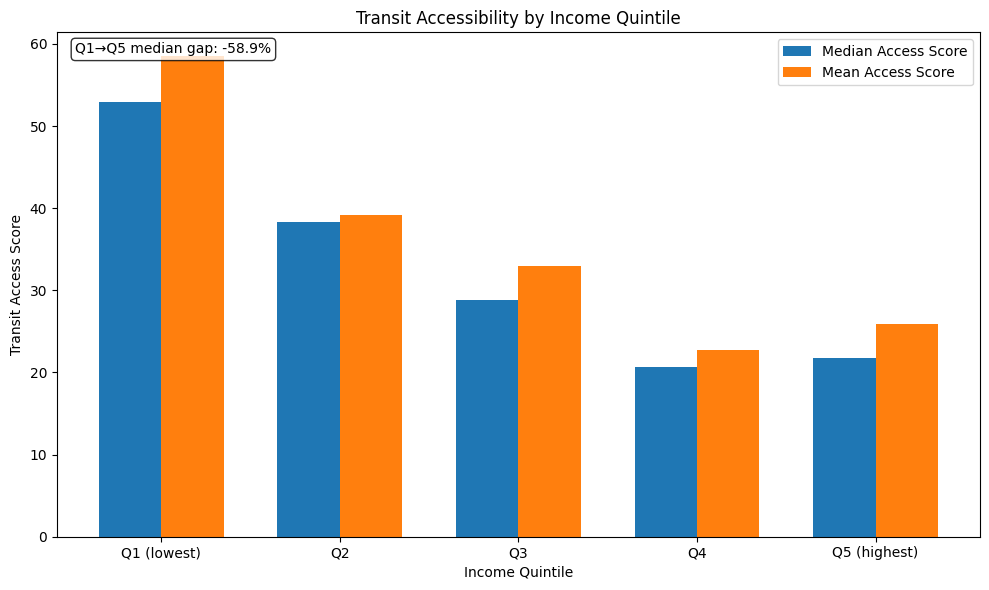

  income_quintile  median_access_score  mean_access_score  neighbourhood_count
0     Q1 (lowest)                52.95              58.49                   48
1              Q2                38.28              39.21                   47
2              Q3                28.83              32.92                   47
3              Q4                20.64              22.77                   47
4    Q5 (highest)                21.78              25.94                   48


In [54]:
# === FIGURE 1: equity_quintile.png ===
# Accessibility comparison by income quintile (Q1-Q5)
#
# INSTRUCTIONS FOR SUDIPTA:
# 1. Run eq.travel_time_equity_report() to get quintile data
# 2. Create a bar chart: x=income quintile, y=median_access_score
# 3. Add a second bar for mean_access_score (grouped)
# 4. Annotate the Q1-Q5 gap percentage
# 5. Title: "Transit Accessibility by Income Quintile"
#
# Or load from parquet:
#   report = pd.read_parquet(teammate_dir / "equity_report.parquet")

report = eq.travel_time_equity_report()
if not report.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    x = range(len(report))
    width = 0.35
    ax.bar([i - width/2 for i in x], report['median_access_score'], width, label='Median Access Score')
    ax.bar([i + width/2 for i in x], report['mean_access_score'], width, label='Mean Access Score')
    ax.set_xlabel('Income Quintile')
    ax.set_ylabel('Transit Access Score')
    ax.set_title('Transit Accessibility by Income Quintile')
    ax.set_xticks(x)
    ax.set_xticklabels(report['income_quintile'])
    ax.legend()

     # Annotate Q1-Q5 gap percentage using median access score
    try:
        q1 = report.loc[report["income_quintile"].astype(str).str.upper().str.contains("Q1"),"median_access_score"].iloc[0]
        q5 = report.loc[report["income_quintile"].astype(str).str.upper().str.contains("Q5"),"median_access_score"].iloc[0]
        
        if q1 != 0:
            gap_pct = ((q5 - q1) / q1) * 100
            ax.text(
                0.02,
                0.98,
                f"Q1→Q5 median gap: {gap_pct:.1f}%",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
            )
    except Exception:
        pass


    plt.tight_layout()

    if save_figures:
        fig.savefig(figures_dir / 'equity_quintile.png', dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)
    print(report[['income_quintile', 'median_access_score', 'mean_access_score', 'neighbourhood_count']])
else:
    save_placeholder_figure('equity_quintile.png',
        'Placeholder: Run eq.travel_time_equity_report()\nBar chart Q1-Q5 median/mean access scores',
        report_name=report_name, figures_dir=str(figures_dir), dpi=dpi, enabled=save_figures)
     

**Interpretation.** Transit accessibility is highest in the lowest-income quintile (Q1) and decreases across higher-income quintiles. The Q1→Q5 median gap is about **-58.9%**, suggesting that lower-income neighbourhoods tend to have substantially better transit accessibility than higher-income neighbourhoods under the current network. This pattern is consistent with transit supply being more concentrated in denser, lower-income urban areas.

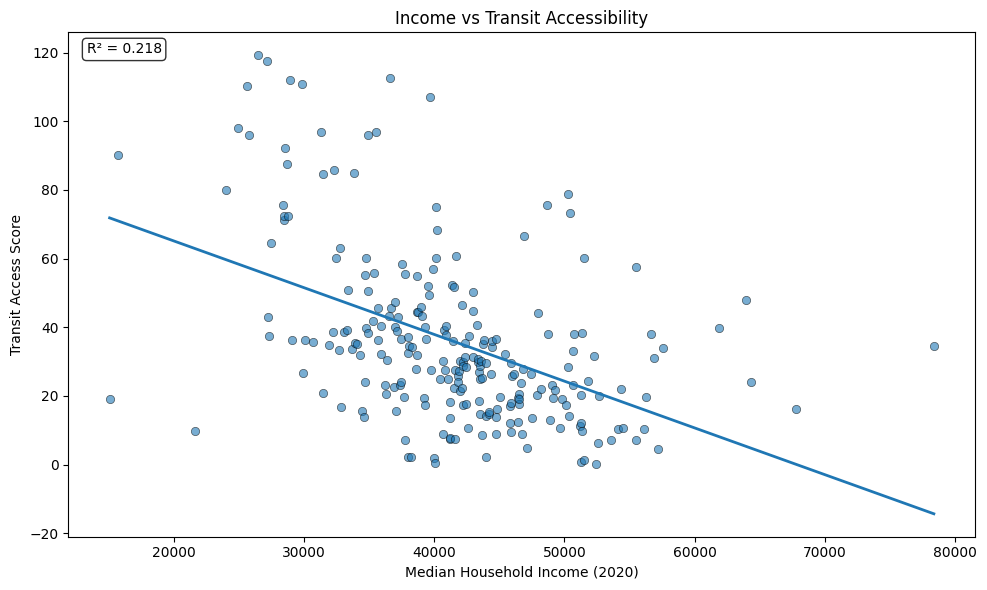

   median_household_income_2020  transit_access_score
0                       15076.0               19.0546
1                       15741.0               90.1274
2                       21596.0                9.7777
3                       23996.0               79.8514
4                       24930.0               98.1339
Rows used: 237


In [55]:
# === FIGURE 2: poverty_correlation.png ===
# Poverty-transit scatter with regression line
#
# INSTRUCTIONS FOR SUDIPTA:
# 1. Run eq.poverty_transit_correlation() to get scatter data
# 2. Scatter: x=median_household_income_2020, y=transit_access_score
# 3. Add OLS regression line + R-squared annotation
# 4. Colour by has_poverty_zone if available
# 5. Title: "Income vs Transit Accessibility"
#
# Or load: poverty = pd.read_parquet(teammate_dir / "poverty_correlation.parquet")

poverty = eq.poverty_transit_correlation()

if not poverty.empty and 'transit_access_score' in poverty.columns:
    fig, ax = plt.subplots(figsize=(10, 6))

    xcol = "median_household_income_2020"
    ycol = "transit_access_score"

    plot_df = poverty[[xcol, ycol] + (["has_poverty_zone"] if "has_poverty_zone" in poverty.columns else [])].dropna()

    # Scatter, colored by poverty zone if available
    if "has_poverty_zone" in plot_df.columns:
        for label, group in plot_df.groupby("has_poverty_zone"):
            ax.scatter(
                group[xcol],
                group[ycol],
                alpha=0.7,
                edgecolors="black",
                linewidths=0.5,
                label=f"Poverty zone: {label}",
            )
        ax.legend()
    else:
        ax.scatter(
            plot_df[xcol],
            plot_df[ycol],
            alpha=0.6,
            edgecolors="black",
            linewidths=0.5,
        )

    # OLS line using numpy polyfit
    if len(plot_df) >= 2:
        import numpy as np

        x = plot_df[xcol].to_numpy()
        y = plot_df[ycol].to_numpy()

        slope, intercept = np.polyfit(x, y, 1)
        y_pred = slope * x + intercept

        order = np.argsort(x)
        ax.plot(x[order], y_pred[order], linewidth=2)

        # R-squared
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else float("nan")

        ax.text(
            0.02,
            0.98,
            f"R² = {r_squared:.3f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        )

    ax.set_xlabel("Median Household Income (2020)")
    ax.set_ylabel("Transit Access Score")
    ax.set_title("Income vs Transit Accessibility")
    plt.tight_layout()

    if save_figures:
        fig.savefig(
            figures_dir / "poverty_correlation.png",
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

    print(plot_df.head())
    print(f"Rows used: {len(plot_df)}")
else:
    save_placeholder_figure(
        "poverty_correlation.png",
        "Placeholder: Run eq.poverty_transit_correlation()\nScatter + regression line",
        report_name=report_name,
        figures_dir=str(figures_dir),
        dpi=dpi,
        enabled=save_figures,
    )

**Interpretation.** The scatter plot shows a **negative relationship** between neighbourhood income and transit accessibility. The fitted regression line slopes downward, and the model gives **R² = 0.218**, meaning income explains some, but not most, of the variation in access. In general, higher-income neighbourhoods tend to have lower transit access scores, though the spread of points shows substantial variation across neighbourhoods.

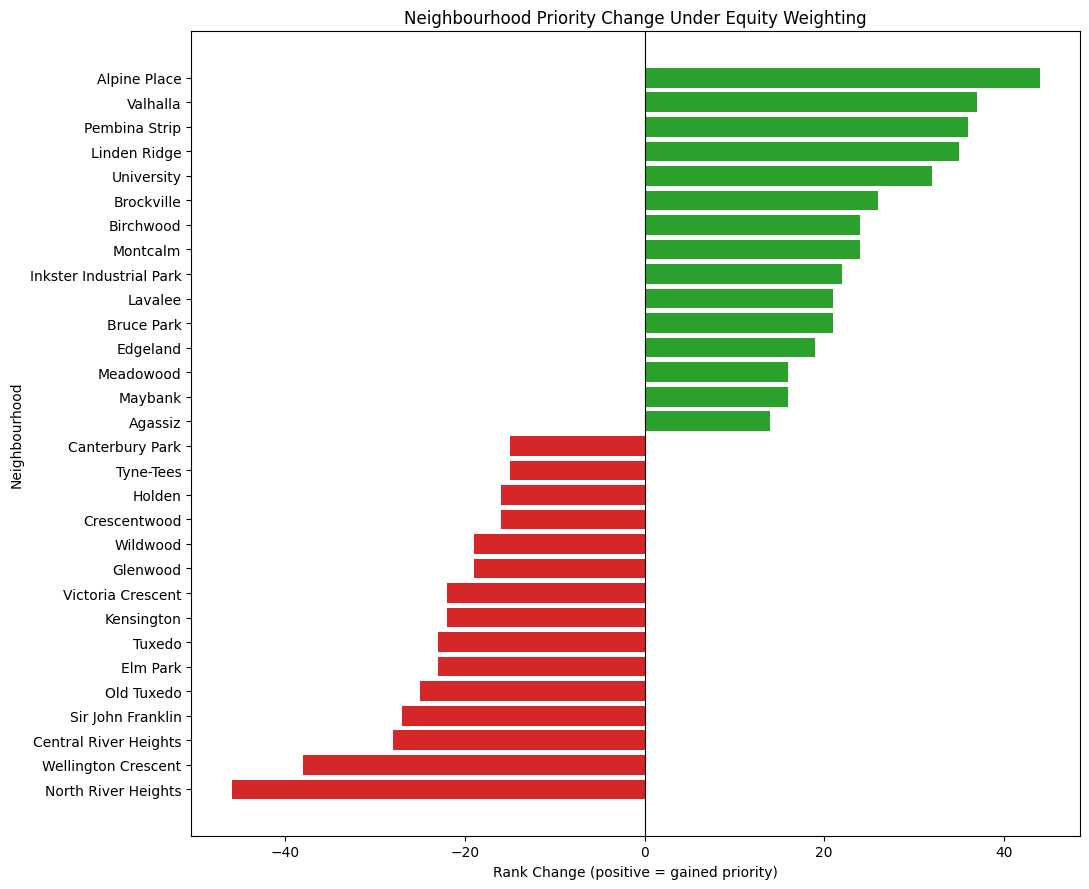

Reprioritized: 209/237 (88.2%)
     neighbourhood  rank_change  vulnerability_index
100   Alpine Place           44               4.8677
158       Valhalla           37               4.6230
83   Pembina Strip           36               5.5071
177   Linden Ridge           35               4.7306
91      University           32               3.3491


In [56]:
# === FIGURE 3: counterfactual_rerank.png ===
# Prescriptive counterfactual: rank change under equity weighting
#
# INSTRUCTIONS FOR SUDIPTA:
# 1. Run eq.equity_weighted_accessibility() to get reranking data
# 2. Horizontal bar chart: y=neighbourhood (top 15 gainers/losers), x=rank_change
# 3. Colour: green for gained priority, red for lost priority
# 4. Title: "Neighbourhood Priority Change Under Equity Weighting"
#
# Or load: cf = pd.read_parquet(teammate_dir / "counterfactual.parquet")

# === FIGURE 3: counterfactual_rerank.png ===
# Prescriptive counterfactual: rank change under equity weighting

cf = eq.equity_weighted_accessibility()

if not cf.empty:
    top_gainers = cf.nlargest(15, 'rank_change')
    top_losers = cf.nsmallest(15, 'rank_change')
    show = pd.concat([top_gainers, top_losers]).sort_values('rank_change')

    fig, ax = plt.subplots(figsize=(11, 9))
    colours = ['#2ca02c' if v > 0 else '#d62728' for v in show['rank_change']]

    ax.barh(show['neighbourhood'], show['rank_change'], color=colours)
    ax.set_xlabel('Rank Change (positive = gained priority)')
    ax.set_ylabel('Neighbourhood')
    ax.set_title('Neighbourhood Priority Change Under Equity Weighting')
    ax.axvline(x=0, color='black', linewidth=0.8)

    plt.tight_layout()

    if save_figures:
        fig.savefig(
            figures_dir / 'counterfactual_rerank.png',
            dpi=dpi,
            bbox_inches='tight',
            facecolor='white'
        )

    plt.show()
    plt.close(fig)

    reprioritized = (cf['rank_change'].abs() > 0).sum()
    print(f"Reprioritized: {reprioritized}/{len(cf)} ({100*reprioritized/len(cf):.1f}%)")
    print(cf.nlargest(5, 'rank_change')[['neighbourhood', 'rank_change', 'vulnerability_index']])
else:
    save_placeholder_figure(
        'counterfactual_rerank.png',
        'Placeholder: Run eq.equity_weighted_accessibility()\nRank change horizontal bars',
        report_name=report_name,
        figures_dir=str(figures_dir),
        dpi=dpi,
        enabled=save_figures
    )

**Interpretation.** Applying equity weighting changes the priority ranking of many neighbourhoods. In total, **209 of 237 neighbourhoods (88.2%)** are reprioritized, showing that equity-based weighting has a substantial effect on which areas appear most urgent for intervention. Positive rank changes indicate neighbourhoods that gain priority under an equity lens, while negative changes indicate neighbourhoods that lose priority relative to the baseline ranking.

In [57]:
# === Export parquets for teammate use ===
export_dir = Path("../data/exports/teammate")
export_dir.mkdir(parents=True, exist_ok=True)

for name, data in [
    ("equity_report", eq.travel_time_equity_report()),
    ("poverty_correlation", eq.poverty_transit_correlation()),
    ("counterfactual", eq.equity_weighted_accessibility()),
]:
    if not data.empty:
        data.to_parquet(export_dir / f"{name}.parquet")
        data.to_csv(export_dir / f"{name}.csv", index=False)
        print(f"  {name}: {len(data)} rows")
    else:
        print(f"  {name}: EMPTY — check DB")

  equity_report: 5 rows
  poverty_correlation: 237 rows
  counterfactual: 237 rows
